# Por que calibrar

**Tema:** Avaliação e Validação de Modelos › Calibração de Probabilidades

Este módulo não tem `teoria.pdf`: a teoria mora aqui, ao lado do código
que a demonstra. Neste notebook definimos o que é uma probabilidade
calibrada, separamos calibração de discriminação (um modelo pode ter
AUC excelente e probabilidades que não valem nada), construímos o
diagrama de confiabilidade e o Brier score do zero, decompomos o Brier
em três parcelas e mostramos por que cada família de modelos descalibra
do seu jeito. Fechamos com o caso mais comum de descalibração em
produção: o que a reamostragem do tema 3 faz com as probabilidades.

## Por que este módulo existe

Um modelo diz "0,80" para um cliente. O que esse número significa? Se o
modelo é **calibrado**, significa que, entre todos os clientes para os
quais ele diz 0,80, cerca de 80% de fato têm o desfecho. Se não é, 0,80
é só um escore: serve para ordenar clientes, não para calcular nada.

A diferença importa quando a probabilidade entra numa conta. Alguns
exemplos do mercado:

- **Crédito:** a perda esperada de um empréstimo é
  $PD \times LGD \times EAD$ (probabilidade de default × perda dado o
  default × exposição). Uma $PD$ inflada em 30% infla a provisão em 30%
  e o preço do crédito junto; uma $PD$ deflacionada subestima a perda e
  aparece no balanço um ano depois.
- **Seguros:** o prêmio é a probabilidade de sinistro vezes a
  severidade, mais margem. Descalibrar é cobrar errado de todo mundo.
- **Publicidade:** um leilão de anúncio paga $CTR \times$ valor do
  clique. Um modelo de $CTR$ que superestima faz a empresa pagar caro
  por impressões que não convertem.
- **Saúde:** "risco de 12% de readmissão" só orienta uma decisão
  clínica se 12% for 12%.
- **Decisão por custo (módulo 1 deste tema):** o limiar ótimo
  $C_{FP}/(C_{FP} + C_{FN})$ é um limiar sobre a **probabilidade**. Com
  probabilidades descalibradas, o limiar teórico cai no lugar errado.

Quando a saída do modelo só ordena (um ranking de leads para a equipe
de vendas ligar de cima para baixo), calibração não importa, e a AUC
basta. Saber em qual dos dois casos você está é a primeira decisão do
módulo.

**Analogia.** Um meteorologista que diz "70% de chance de chuva" está
calibrado se, nos dias em que disse 70%, choveu em 7 de cada 10. É
possível ser um ótimo ordenador de dias (sempre acertar quais dias são
mais chuvosos que outros) e ainda assim dizer 70% quando a frequência
real é 40%. O primeiro talento chama-se **discriminação**; o segundo,
**calibração**. Meteorologistas são, historicamente, a profissão mais
bem calibrada que existe (o Brier score nasceu em 1950 para medi-los), e
o motivo é que eles recebem feedback todos os dias.

### O que você vai conseguir fazer ao final

- Definir calibração e distingui-la de discriminação.
- Construir e ler um diagrama de confiabilidade; escolher os bins.
- Calcular Brier, log loss e ECE do zero e saber o que cada um pune.
- Decompor o Brier em incerteza, resolução e confiabilidade.
- Prever, pela família do modelo, a forma da descalibração.
- Explicar por que reamostrar ou ponderar classes descalibra, e
  corrigir analiticamente.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

rng = np.random.default_rng(651)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR, CINZA = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100", "#5A5A5A"
print("pronto")

pronto


## 1. Definição, e por que a AUC não enxerga calibração

Um modelo que devolve $\hat{p}(x)$ é **calibrado** quando

$$P\big(Y = 1 \mid \hat{p}(x) = p\big) = p \quad \text{para todo } p.$$

É uma afirmação sobre **frequências condicionais**, não sobre acertos
individuais. Não existe "esta previsão de 0,8 estava calibrada"; existe
"as previsões perto de 0,8 acertam 80% das vezes".

A AUC (módulo 1) só depende da **ordem** dos escores: qualquer
transformação monótona crescente de $\hat{p}$ (elevar ao quadrado,
dividir por 2, passar por uma sigmoide) dá exatamente a mesma AUC. A
calibração é destruída por qualquer uma delas. Os dois conceitos são
independentes, e a demonstração cabe em quatro linhas:

In [2]:
n = 20000
p_verdadeira = rng.beta(2, 5, n)                       # a probabilidade real de cada caso
y = (rng.random(n) < p_verdadeira).astype(int)
candidatos = {"calibrado (p real)": p_verdadeira,
              "ao quadrado": p_verdadeira ** 2,
              "raiz quadrada": np.sqrt(p_verdadeira),
              "espremido para o meio": 0.3 + 0.4 * p_verdadeira}
for nome, p in candidatos.items():
    print(f"{nome:>22s}: AUC = {roc_auc_score(y, p):.4f} | Brier = {brier_score_loss(y, p):.4f} | "
          f"log loss = {log_loss(y, p):.4f}")

    calibrado (p real): AUC = 0.7215 | Brier = 0.1792 | log loss = 0.5347
           ao quadrado: AUC = 0.7215 | Brier = 0.2163 | log loss = 0.6971
         raiz quadrada: AUC = 0.7215 | Brier = 0.2294 | log loss = 0.6502
 espremido para o meio: AUC = 0.7215 | Brier = 0.2044 | log loss = 0.5997


A mesma AUC quatro vezes, com probabilidades que significam coisas
diferentes. O Brier e a log loss, que dependem do **valor** de $\hat{p}$,
separam os quatro; o calibrado vence nos dois.

## 2. O diagrama de confiabilidade do zero

A ferramenta visual: agrupe as previsões em bins, e em cada bin compare
a previsão média com a frequência observada de positivos. Um modelo
calibrado fica na diagonal. Acima da diagonal, ele **subestima** (diz
0,3 e acontece 0,5); abaixo, **superestima**.

Duas escolhas de bins:

- **largura fixa** (`[0, 0.1), [0.1, 0.2), ...`): fácil de ler, mas os
  bins extremos podem ter pouquíssimos casos e a frequência observada
  neles é ruído.
- **frequência fixa** (quantis de $\hat{p}$): cada bin tem o mesmo
  número de casos, então cada ponto tem a mesma precisão. É a escolha
  mais segura; o custo é que os bins não têm centros "redondos".

O **ECE** (*expected calibration error*) resume o diagrama num número:
a distância média entre previsão e frequência, ponderada pelo tamanho
do bin.

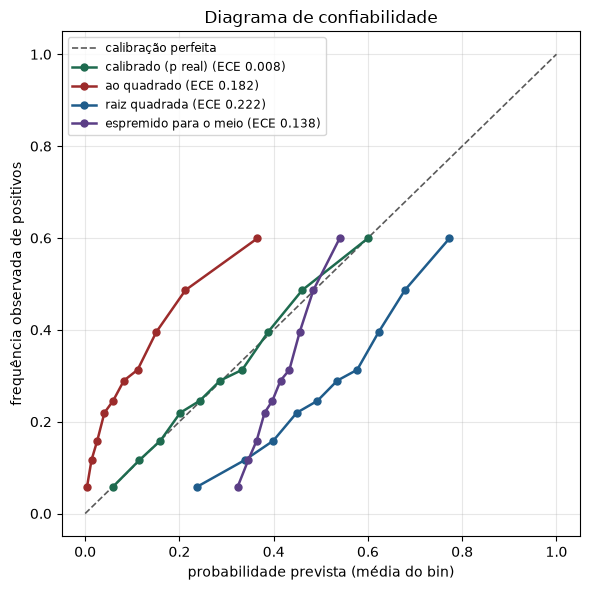

In [3]:
def diagrama(y, p, n_bins=10, estrategia="quantil"):
    """Devolve um DataFrame com um bin por linha: previsão média, frequência observada, n."""
    if estrategia == "quantil":
        bordas = np.quantile(p, np.linspace(0, 1, n_bins + 1))
        bordas[0], bordas[-1] = 0, 1
    else:
        bordas = np.linspace(0, 1, n_bins + 1)
    qual = np.clip(np.searchsorted(bordas, p, side="right") - 1, 0, n_bins - 1)
    linhas = []
    for b in range(n_bins):
        m = qual == b
        if m.sum() == 0:
            continue
        linhas.append({"bin": b, "previsão média": p[m].mean(), "frequência observada": y[m].mean(),
                       "n": int(m.sum())})
    return pd.DataFrame(linhas)

def ece(y, p, n_bins=10, estrategia="quantil"):
    d = diagrama(y, p, n_bins, estrategia)
    return np.sum(d["n"] / len(y) * np.abs(d["previsão média"] - d["frequência observada"]))

def desenha(ax, y, p, rotulo, cor, n_bins=10, estrategia="quantil"):
    d = diagrama(y, p, n_bins, estrategia)
    ax.plot(d["previsão média"], d["frequência observada"], marker="o", ms=5, lw=1.8, color=cor,
            label=f"{rotulo} (ECE {ece(y, p, n_bins, estrategia):.3f})")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], color=CINZA, ls="--", lw=1.2, label="calibração perfeita")
for (nome, p), cor in zip(candidatos.items(), [VERDE, VERMELHO, AZUL, ROXO]):
    desenha(ax, y, p, nome, cor)
ax.set_xlabel("probabilidade prevista (média do bin)"); ax.set_ylabel("frequência observada de positivos")
ax.set_title("Diagrama de confiabilidade"); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

**Leitura esperada:** o quadrado fica **acima** da diagonal (diz 0,1
quando acontece 0,3: subestima), a raiz fica **abaixo** (superestima), e
o "espremido" cruza a diagonal no meio, subestimando embaixo e
superestimando em cima. As quatro curvas têm a mesma AUC. Esse é o
retrato do que a AUC não enxerga.

## 3. Brier score e a decomposição de Murphy

O **Brier score** é o erro quadrático médio entre a probabilidade
prevista e o desfecho:

$$\text{Brier} = \frac{1}{n}\sum_{i=1}^{n} (\hat{p}_i - y_i)^2$$

Vai de 0 (perfeito) a 1; prever sempre a prevalência $\bar{y}$ dá
$\bar{y}(1 - \bar{y})$, que é o baseline a bater (0,25 numa base
50/50, 0,09 numa base com 10% de positivos). É uma **regra de pontuação
própria** (*proper scoring rule*): a única forma de minimizá-lo em
esperança é reportar a probabilidade verdadeira. Mentir para cima ou
para baixo sempre piora o escore esperado. A log loss tem a mesma
propriedade, com uma punição muito mais severa para previsões
confiantes e erradas (0,99 num negativo custa $-\ln 0{,}01 \approx 4{,}6$;
no Brier, custa 0,98).

Murphy (1973) mostrou que, com previsões agrupadas em bins, o Brier se
decompõe em três parcelas:

$$\text{Brier} = \underbrace{\bar{y}(1-\bar{y})}_{\text{incerteza}} \;-\; \underbrace{\frac{1}{n}\sum_b n_b(\bar{y}_b - \bar{y})^2}_{\text{resolução}} \;+\; \underbrace{\frac{1}{n}\sum_b n_b(\bar{p}_b - \bar{y}_b)^2}_{\text{confiabilidade}}$$

- **Incerteza**: a variância do desfecho; não depende do modelo. É o
  ruído do módulo anterior, em versão binária.
- **Resolução** (entra subtraindo): quanto as frequências observadas
  por bin se afastam da prevalência global. Mede **discriminação**: um
  modelo cujos bins têm frequências 5%, 20%, 60% separa bem; um cujos
  bins todos têm 30% não separa nada.
- **Confiabilidade** (entra somando): a distância quadrática entre
  previsão e frequência em cada bin. É a calibração; zero é perfeito.

A decomposição responde à pergunta "o Brier está alto por quê?", e as
duas respostas têm remédios diferentes: falta de resolução se resolve
com um modelo melhor; falta de confiabilidade se resolve
**recalibrando**, sem tocar no modelo (próximo notebook).

In [4]:
def murphy(y, p, n_bins=10):
    d = diagrama(y, p, n_bins)
    ybar = y.mean()
    w = d["n"] / len(y)
    incerteza = ybar * (1 - ybar)
    resolucao = np.sum(w * (d["frequência observada"] - ybar) ** 2)
    confiabilidade = np.sum(w * (d["previsão média"] - d["frequência observada"]) ** 2)
    return pd.Series({"incerteza": incerteza, "resolução": resolucao, "confiabilidade": confiabilidade,
                      "Brier (soma)": incerteza - resolucao + confiabilidade,
                      "Brier (direto)": brier_score_loss(y, p)})

print(pd.DataFrame({nome: murphy(y, p) for nome, p in candidatos.items()}).round(4).to_string())

                calibrado (p real)  ao quadrado  raiz quadrada  espremido para o meio
incerteza                   0.2051       0.2051         0.2051                 0.2051
resolução                   0.0254       0.0254         0.0254                 0.0254
confiabilidade              0.0001       0.0371         0.0502                 0.0251
Brier (soma)                0.1799       0.2169         0.2300                 0.2049
Brier (direto)              0.1792       0.2163         0.2294                 0.2044


A resolução é (quase) a mesma nas quatro colunas, porque as quatro
ordenam igual e os bins por quantil contêm os mesmos casos; o que muda é
a confiabilidade. A soma reproduz o Brier direto a menos de um resíduo
pequeno, que vem da variação de $\hat{p}$ dentro de cada bin (a
decomposição é exata só para previsões discretas).

## 4. Cada família descalibra do seu jeito

Niculescu-Mizil e Caruana (2005) treinaram dez famílias de modelos em
dezenas de bases e desenharam os diagramas. O padrão se repete até hoje:

| Modelo | Forma típica do diagrama | Por quê |
| :-- | :-- | :-- |
| Regressão logística | na diagonal | otimiza a log loss diretamente; se a forma do modelo está certa, sai calibrada |
| Naive Bayes | extremos demais | assume independência entre features; evidências redundantes se multiplicam e empurram para 0 ou 1 |
| SVM (escore de margem) | não é probabilidade | a margem é uma distância, não uma frequência; precisa de Platt |
| Random Forest | S: espremido para o meio | a média de árvores raramente chega a 0 ou 1. Com muitas árvores profundas e bases grandes, costuma sair perto da diagonal |
| Boosting com freio (early stopping, taxa baixa) | perto da diagonal | otimiza a log loss; a regularização evita a confiança excessiva |
| Boosting sem freio, redes neurais modernas | superconfiantes | treinar até o fim com muita capacidade infla a confiança (Guo et al., 2017) |

Vamos reproduzir o experimento com uma base de risco de crédito
sintética. A probabilidade verdadeira vem de uma logística com uma
interação (para a logística sem interação ter algum viés), e quatro das
oito features são **cópias ruidosas** de outras duas: o tipo de
redundância que existe em qualquer base real (renda e limite do cartão,
idade e tempo de conta) e que o naive Bayes trata como evidência
independente.

`N_TREINO` está exposto: com 8.000 linhas o boosting com freio sai bem;
reduza para 800 e ele também vira superconfiante, porque com poucos
dados 200 iterações já são demais.

prevalência: 37.1% | Brier do oráculo (p verdadeira): 0.1303


C:\Users\mktsi\Documents\FIAP\projetos-pessoais\excercicios-machine-learning\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


                           AUC   Brier  log loss     ECE  confiabilidade  resolução
modelo                                                                             
logística               0.8591  0.1486    0.4538  0.0219          0.0008     0.0870
naive Bayes             0.8452  0.1668    0.5511  0.0870          0.0112     0.0799
SVM (Platt do sklearn)  0.8749  0.1378    0.4334  0.0389          0.0022     0.0995
random forest           0.8779  0.1376    0.4241  0.0133          0.0003     0.0978
boosting com freio      0.8795  0.1378    0.4249  0.0287          0.0012     0.0983
boosting sem freio      0.8624  0.1757    0.8070  0.1425          0.0282     0.0891


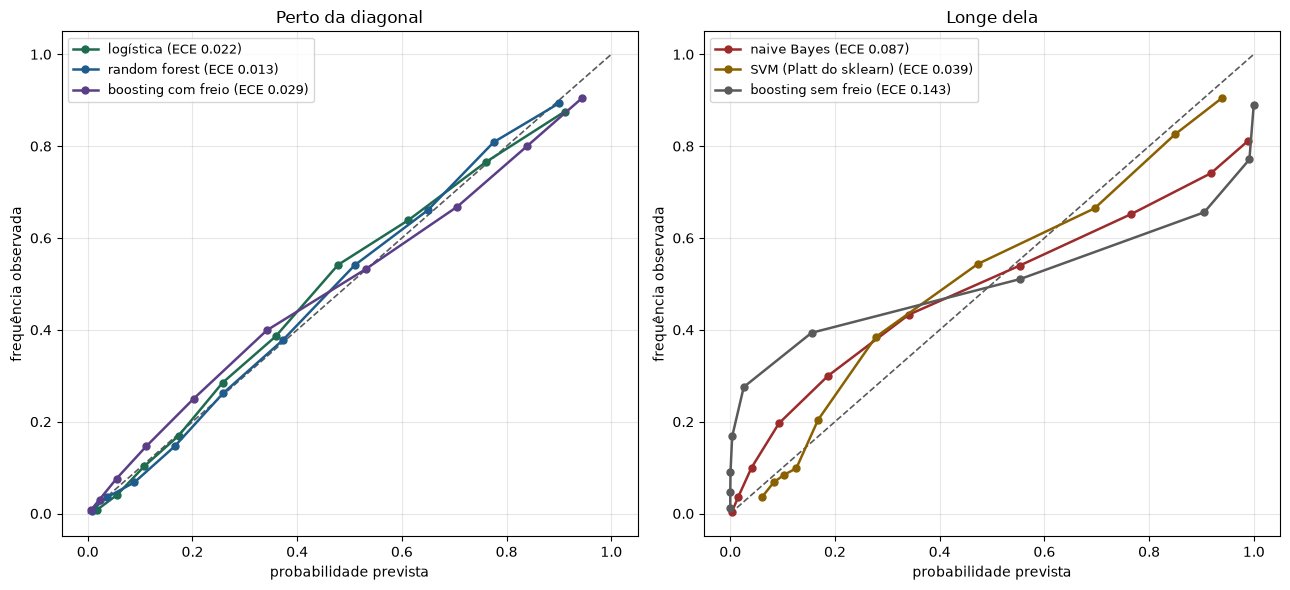

In [5]:
N_TREINO = 8000

def gera_credito(n, semente, intercepto=-1.2):
    g = np.random.default_rng(semente)
    Z = g.normal(0, 1, (n, 4))
    logit = intercepto + 1.8 * Z[:, 0] - 1.4 * Z[:, 1] + 1.0 * Z[:, 2] + 1.2 * Z[:, 0] * Z[:, 1] + 0.6 * Z[:, 3]
    p = 1 / (1 + np.exp(-logit))
    copias = np.column_stack([Z[:, 0] + g.normal(0, 0.4, n), Z[:, 0] + g.normal(0, 0.4, n),
                              Z[:, 1] + g.normal(0, 0.4, n), Z[:, 1] + g.normal(0, 0.4, n)])
    return np.column_stack([Z, copias]), (g.random(n) < p).astype(int), p

X_tr, y_tr, _ = gera_credito(N_TREINO, 1)
X_te, y_te, p_te = gera_credito(20000, 2)
print(f"prevalência: {y_tr.mean():.1%} | Brier do oráculo (p verdadeira): {brier_score_loss(y_te, p_te):.4f}")

modelos = {
    "logística": make_pipeline(StandardScaler(), LogisticRegression()),
    "naive Bayes": GaussianNB(),
    "SVM (Platt do sklearn)": make_pipeline(StandardScaler(), SVC(C=1.0, probability=True, random_state=0)),
    "random forest": RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1),
    "boosting com freio": HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, random_state=0),
    "boosting sem freio": HistGradientBoostingClassifier(max_iter=500, learning_rate=0.3, random_state=0),
}
previsoes, linhas = {}, []
for nome, m in modelos.items():
    p = m.fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
    previsoes[nome] = p
    decomp = murphy(y_te, p)
    linhas.append({"modelo": nome, "AUC": roc_auc_score(y_te, p), "Brier": brier_score_loss(y_te, p),
                   "log loss": log_loss(y_te, p), "ECE": ece(y_te, p),
                   "confiabilidade": decomp["confiabilidade"], "resolução": decomp["resolução"]})
print(pd.DataFrame(linhas).set_index("modelo").round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax in axes:
    ax.plot([0, 1], [0, 1], color=CINZA, ls="--", lw=1.2)
    ax.set_xlabel("probabilidade prevista"); ax.set_ylabel("frequência observada")
for nome, cor in [("logística", VERDE), ("random forest", AZUL), ("boosting com freio", ROXO)]:
    desenha(axes[0], y_te, previsoes[nome], nome, cor)
for nome, cor in [("naive Bayes", VERMELHO), ("SVM (Platt do sklearn)", AMBAR), ("boosting sem freio", CINZA)]:
    desenha(axes[1], y_te, previsoes[nome], nome, cor)
axes[0].set_title("Perto da diagonal"); axes[1].set_title("Longe dela")
axes[0].legend(fontsize=9); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

**Leitura esperada:** a logística fica na diagonal, com um desvio
pequeno no topo vindo da interação que ela não modela. A random forest
e o boosting com freio ficam perto dela, e por isso têm os melhores
Briers. Os três painéis da direita contam a história das falhas: o
naive Bayes diz 0,99 quando acontece 0,8 (as cópias ruidosas entram como
quatro testemunhas independentes que na verdade repetem a mesma coisa);
o boosting sem freio chega a 0 e a 1 em casos que têm 1% e 89% de
chance; e o SVM sai razoável só porque `probability=True` aplica Platt
scaling internamente (com uma CV de 5 folds, que é o que encarece o
`fit`).

Repare na tabela: o ranking por **AUC** e o ranking por **Brier** não
coincidem, e a coluna `confiabilidade` explica a diferença. O naive
Bayes e o boosting sem freio têm resolução parecida com a dos outros
(ordenam bem) e confiabilidade dez vezes pior. É a tabela inteira, e não
uma coluna, que responde "qual modelo usar".

## 5. A descalibração que você mesmo causa: reamostragem

O tema 3 (módulo 5) mostrou que treinar com classes reequilibradas
(undersampling, SMOTE, `class_weight`) muda a **prevalência que o modelo
vê**. As probabilidades saem calibradas para o mundo reequilibrado, não
para o real. Se a base real tem 10% de positivos e o treino tem 50%, o
modelo diz "0,5" para casos que têm 10% de chance.

A correção analítica existe. Se o treino tem prevalência $\pi_t$ e a
produção tem $\pi$, a probabilidade corrigida é

$$p_{\text{corr}} = \frac{p \cdot \frac{\pi}{\pi_t}}{p \cdot \frac{\pi}{\pi_t} + (1 - p)\cdot\frac{1 - \pi}{1 - \pi_t}}$$

que é o teorema de Bayes (tema 1, módulo 5) trocando a priori de treino
pela priori real. Na escala logit é ainda mais simples: subtraia
$\ln\frac{\pi_t}{1-\pi_t} - \ln\frac{\pi}{1-\pi}$ do logit.

prevalência real 14.4% | prevalência no treino reequilibrado 50.0%
                     treino original: AUC 0.8806 | Brier 0.0846 | ECE 0.0174 | média de p̂ 0.136 (prevalência real 0.141)
                treino reequilibrado: AUC 0.8719 | Brier 0.1584 | ECE 0.1858 | média de p̂ 0.326 (prevalência real 0.141)
  reequilibrado + correção de priori: AUC 0.8719 | Brier 0.0933 | ECE 0.0432 | média de p̂ 0.167 (prevalência real 0.141)


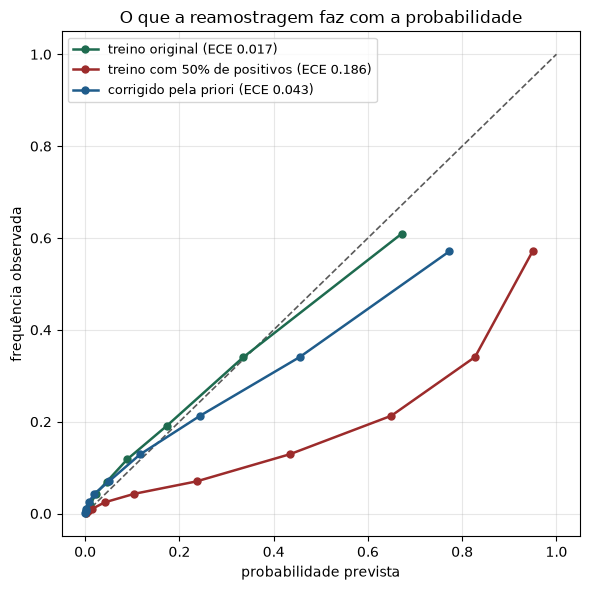

In [6]:
PREVALENCIA_TREINO = 0.5                        # mude para 0.3 ou 0.15 e veja o efeito diminuir

# uma carteira com poucos maus pagadores, como na vida real
X_c, y_c, _ = gera_credito(N_TREINO, 3, intercepto=-3.4)
X_ct, y_ct, _ = gera_credito(20000, 4, intercepto=-3.4)
pos, neg = np.where(y_c == 1)[0], np.where(y_c == 0)[0]
n_neg = int(len(pos) * (1 - PREVALENCIA_TREINO) / PREVALENCIA_TREINO)
idx_bal = np.concatenate([pos, rng.choice(neg, n_neg, replace=False)])
pi_t, pi = y_c[idx_bal].mean(), y_c.mean()

gbm = lambda: HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, random_state=0)
p_orig = gbm().fit(X_c, y_c).predict_proba(X_ct)[:, 1]
p_bal = gbm().fit(X_c[idx_bal], y_c[idx_bal]).predict_proba(X_ct)[:, 1]
razao_pos, razao_neg = pi / pi_t, (1 - pi) / (1 - pi_t)
p_corr = p_bal * razao_pos / (p_bal * razao_pos + (1 - p_bal) * razao_neg)

print(f"prevalência real {pi:.1%} | prevalência no treino reequilibrado {pi_t:.1%}")
for nome, p in [("treino original", p_orig), ("treino reequilibrado", p_bal),
                ("reequilibrado + correção de priori", p_corr)]:
    print(f"{nome:>36s}: AUC {roc_auc_score(y_ct, p):.4f} | Brier {brier_score_loss(y_ct, p):.4f} | "
          f"ECE {ece(y_ct, p):.4f} | média de p̂ {p.mean():.3f} (prevalência real {y_ct.mean():.3f})")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], color=CINZA, ls="--", lw=1.2)
desenha(ax, y_ct, p_orig, "treino original", VERDE)
desenha(ax, y_ct, p_bal, f"treino com {PREVALENCIA_TREINO:.0%} de positivos", VERMELHO)
desenha(ax, y_ct, p_corr, "corrigido pela priori", AZUL)
ax.set_xlabel("probabilidade prevista"); ax.set_ylabel("frequência observada"); ax.legend(fontsize=9)
ax.set_title("O que a reamostragem faz com a probabilidade")
plt.tight_layout(); plt.show()

**Leitura esperada:** a AUC quase não muda (reamostrar não muda a
ordem), a média de $\hat{p}$ dispara para perto da prevalência de treino
e a curva desaba para baixo da diagonal: superestimação sistemática. A
correção de priori devolve a curva para perto da original com uma linha
de código. Esse é o erro mais comum de calibração em produção, e o mais
barato de consertar; ele aparece em todo pipeline que usa SMOTE ou
`class_weight="balanced"` e depois trata a saída como probabilidade.

## 6. Quantos bins? O ECE é sensível

O ECE depende do número de bins, e de um jeito traiçoeiro: com poucos
bins, erros de sinais opostos dentro do mesmo bin se cancelam e o ECE
fica otimista; com muitos, cada bin tem poucos casos e o ruído da
frequência observada infla o ECE. Não existe número certo; existe
reportar qual foi usado e, de preferência, olhar o diagrama.

In [7]:
p_rf = previsoes["random forest"]
print("ECE da random forest em função do número de bins (quantis):")
for nb in [3, 5, 10, 20, 50, 100]:
    print(f"  {nb:3d} bins: {ece(y_te, p_rf, nb):.4f}")
p_teste_pequeno = p_rf[:500]
print("\ncom só 500 casos de teste:")
for nb in [5, 10, 20, 50]:
    print(f"  {nb:3d} bins: {ece(y_te[:500], p_teste_pequeno, nb):.4f}")

ECE da random forest em função do número de bins (quantis):


    3 bins: 0.0101
    5 bins: 0.0119
   10 bins: 0.0133
   20 bins: 0.0157
   50 bins: 0.0188
  100 bins: 0.0223

com só 500 casos de teste:
    5 bins: 0.0400
   10 bins: 0.0409
   20 bins: 0.0458
   50 bins: 0.0776


Com 20 mil casos, o ECE varia pouco entre 5 e 50 bins. Com 500 casos,
ele dobra ao ir de 5 para 50 bins, e o aumento é ruído, não
descalibração. Regra prática: pelo menos 100 casos por bin, e o Brier
(que não usa bins) como métrica principal quando a base de teste é
pequena.

## 7. Antes de calibrar, decida se precisa

Um roteiro de três perguntas, na ordem:

1. **A probabilidade entra numa conta?** Preço, provisão, valor esperado,
   limiar derivado de custo, combinação com outro modelo. Se sim,
   calibração é requisito. Se a saída só ordena, pare aqui; otimize AUC
   ou precisão@k.
2. **O modelo é de uma família que descalibra?** Floresta, naive Bayes,
   SVM, boosting com regularização pesada, redes neurais: sim. Logística
   sem reamostragem: em geral não. Qualquer modelo treinado com
   reamostragem ou pesos de classe: **sim, sempre**.
3. **Tenho dados separados para calibrar e para avaliar?** A calibração
   é um ajuste e, como qualquer ajuste, sobreajusta se for feita na mesma
   base em que se mede. O próximo notebook cuida disso.

## O que levar deste notebook

- Calibrado: entre os casos previstos com $p$, a fração de positivos é
  $p$. É uma propriedade de frequências, não de previsões individuais.
- AUC mede ordem e é cega a calibração; Brier e log loss medem o valor
  e são regras próprias: reportar a verdade é a única forma de
  minimizá-los.
- O diagrama de confiabilidade, com bins por quantil e pelo menos 100
  casos por bin, mostra a forma da descalibração. O ECE a resume, mas
  depende dos bins.
- Brier = incerteza − resolução + confiabilidade: falta de resolução
  pede modelo melhor; falta de confiabilidade pede recalibração.
- Cada família descalibra com uma forma previsível. Reamostragem e pesos
  de classe descalibram qualquer família, e a correção de priori conserta
  com uma linha.

→ Próximo: **Platt scaling e regressão isotônica**, os dois métodos que
consertam a forma sem tocar na ordem.